In [2]:
"""
LEO to GEO Low Thrust Orbit Transfer using Basilisk

This script simulates a spacecraft performing a low-thrust spiral transfer
from Low Earth Orbit (LEO) to Geostationary Earth Orbit (GEO) using continuous
tangential thrust with Basilisk's astrodynamics framework.

Matches the dynamics of the reference scipy implementation.

Author: Based on Basilisk examples
"""

import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from Basilisk import __path__
from Basilisk.architecture import messaging
from Basilisk.simulation import spacecraft
from Basilisk.simulation import extForceTorque
from Basilisk.simulation import simpleNav
from Basilisk.utilities import SimulationBaseClass
from Basilisk.utilities import macros
from Basilisk.utilities import unitTestSupport
from Basilisk.utilities import simIncludeGravBody

bskPath = __path__[0]

In [3]:
def run(show_plots=True):
    """
    Main simulation function for LEO to GEO low thrust transfer
    
    Args:
        show_plots (bool): Whether to display plots at the end
    """
    
    # --- Constants (matching reference simulation) ---
    R_E = 6378.0  # km, Earth radius
    mu = 3.986e5  # km^3/s^2, Earth gravitational parameter
    
    # Initial orbit parameters
    a_init = 500.0  # km, altitude
    r_init = a_init + R_E  # km, orbital radius
    v_init = np.sqrt(mu / r_init)  # km/s, circular orbit velocity
    
    # Final orbit parameters
    a_final = 35000.0  # km, altitude (matching reference)
    r_final = a_final + R_E  # km
    
    # Spacecraft parameters
    m_0 = 1000.0  # kg, initial mass
    
    # Engine parameters (matching reference)
    T = 1.0 / 1000.0  # kN (1 N converted to kN)
    I_sp = 10000.0  # s, specific impulse
    g_0 = 9.807e-3  # km/s^2, standard gravity
    
    print("=" * 60)
    print("LEO to GEO Low Thrust Transfer - Basilisk Implementation")
    print("=" * 60)
    print(f"Initial Altitude: {a_init} km")
    print(f"Final Target Altitude: {a_final} km")
    print(f"Max Thrust: {T*1000} N")
    print(f"Specific Impulse: {I_sp} s")
    print(f"Initial Mass: {m_0} kg")
    print(f"Initial Speed: {v_init:.3f} km/s")
    print("=" * 60)
    
    # --- Simulation Parameters ---
    dynTaskName = "dynTask"
    dynProcessName = "dynProcess"
    
    # Create simulation
    scSim = SimulationBaseClass.SimBaseClass()
    
    # Create process and task
    dynProcess = scSim.CreateNewProcess(dynProcessName)
    simTimeStep = macros.sec2nano(1.0)  # 1 second time steps for accuracy
    dynProcess.addTask(scSim.CreateNewTask(dynTaskName, simTimeStep))
    
    # --- Spacecraft Setup ---
    scObject = spacecraft.Spacecraft()
    scObject.ModelTag = "LEO-GEO-Spacecraft"
    
    # Mass properties
    I = [900., 0., 0.,
         0., 800., 0.,
         0., 0., 600.]
    scObject.hub.mHub = m_0
    scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    
    # Initial conditions - circular LEO orbit in XY plane
    # Convert km to meters for Basilisk
    scObject.hub.r_CN_NInit = [[r_init * 1000.0], [0.0], [0.0]]  # m
    scObject.hub.v_CN_NInit = [[0.0], [v_init * 1000.0], [0.0]]  # m/s
    scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]  # rad/s
    
    scSim.AddModelToTask(dynTaskName, scObject)
    
    # --- Gravity Setup ---
    # Use gravity factory to set up Earth gravity with exact mu
    gravFactory = simIncludeGravBody.gravBodyFactory()
    earth = gravFactory.createEarth()
    earth.isCentralBody = True
    earth.mu = mu * 1e9  # Convert km^3/s^2 to m^3/s^2 for exact match
    gravFactory.addBodiesTo(scObject)
    
    # --- External Force for Tangential Thrust ---
    extFTObject = extForceTorque.ExtForceTorque()
    extFTObject.ModelTag = "tangentialThrust"
    scObject.addDynamicEffector(extFTObject)
    scSim.AddModelToTask(dynTaskName, extFTObject)
    
    # --- Navigation ---
    sNavObject = simpleNav.SimpleNav()
    sNavObject.ModelTag = "SimpleNavigation"
    scSim.AddModelToTask(dynTaskName, sNavObject)
    sNavObject.scStateInMsg.subscribeTo(scObject.scStateOutMsg)
    
    # --- Data Logging ---
    samplingTime = macros.sec2nano(60.0)  # Log every 60 seconds
    scStateLog = scObject.scStateOutMsg.recorder(samplingTime)
    scSim.AddModelToTask(dynTaskName, scStateLog)
    
    # --- Initialize Simulation ---
    scSim.InitializeSimulation()
    
    # --- THRUST PHASE ---
    print("\nStarting Thrust Phase...")
    
    current_time = 0
    max_time = macros.day2nano(200.0)  # 200 days max
    update_interval = macros.sec2nano(10.0)  # Update thrust every 10 seconds
    
    thrust_phase_complete = False
    orbit_count = 0
    last_y = 0.0
    
    # Storage for detailed trajectory
    thrust_positions = []
    thrust_velocities = []
    thrust_times = []
    thrust_masses = []
    
    while current_time < max_time and not thrust_phase_complete:
        # Execute simulation step
        scSim.ConfigureStopTime(current_time + update_interval)
        scSim.ExecuteSimulation()
        
        # Get current state (in meters and m/s)
        r_BN_N = scObject.dynManager.getStateObject("hubPosition").getState()
        v_BN_N = scObject.dynManager.getStateObject("hubVelocity").getState()
        current_mass = scObject.hub.mHub
        
        # Convert to km and km/s for calculations
        r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
        v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
        
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)
        
        # Store trajectory data
        thrust_positions.append(r_vec.copy())
        thrust_velocities.append(v_vec.copy())
        thrust_times.append(current_time * macros.NANO2SEC)
        thrust_masses.append(current_mass)
        
        # Check for orbit crossing (Y coordinate sign change)
        current_y = r_vec[1]
        if last_y < 0 and current_y >= 0 and current_time > 0:
            orbit_count += 1
        last_y = current_y
        
        # Check if reached destination
        if r_mag >= r_final:
            thrust_phase_complete = True
            print(f"\nThrust Phase Complete!")
            print(f"Reached target radius at: {current_time * macros.NANO2SEC / 86400.0:.4f} days")
            break
        
        # Calculate tangential thrust force (in velocity direction)
        if v_mag > 0:
            # Thrust direction is velocity direction (tangential)
            thrust_dir = v_vec / v_mag
            # Thrust magnitude in Newtons
            thrust_force_kN = T * thrust_dir  # kN
            # Convert to Newtons for Basilisk
            thrust_force_N = thrust_force_kN * 1000.0  # N
            
            # Apply thrust in inertial frame
            extFTObject.extForce_N = [
                [thrust_force_N[0]],
                [thrust_force_N[1]],
                [thrust_force_N[2]]
            ]
        else:
            extFTObject.extForce_N = [[0.0], [0.0], [0.0]]
        
        # Update mass (fuel consumption): dm/dt = -T / (I_sp * g_0)
        dt = update_interval * macros.NANO2SEC  # seconds
        dm = -T / (I_sp * g_0) * dt  # kg (T in kN, result in kg)
        scObject.hub.mHub = max(10.0, current_mass + dm)  # Minimum 10 kg
        
        current_time += update_interval
    
    thrust_end_time = current_time
    final_thrust_mass = scObject.hub.mHub
    propellant_used = m_0 - final_thrust_mass
    
    print(f"Time of flight: {thrust_end_time * macros.NANO2SEC / 86400.0:.4f} days")
    print(f"Number of orbits: {orbit_count}")
    print(f"Propellant used: {propellant_used:.4f} kg")
    print(f"Final speed (thrust cutoff): {v_mag:.3f} km/s")
    
    # --- COAST PHASE ---
    print("\nStarting Coast Phase...")
    
    # Turn off thrust
    extFTObject.extForce_N = [[0.0], [0.0], [0.0]]
    
    # Coast for 14 days
    t_coast = macros.day2nano(14.0)
    coast_end_time = thrust_end_time + t_coast
    
    coast_positions = []
    coast_velocities = []
    coast_times = []
    
    # Run coast phase with frequent sampling
    coast_sample_interval = macros.sec2nano(600.0)  # Sample every 10 minutes
    
    while current_time < coast_end_time:
        sample_time = min(current_time + coast_sample_interval, coast_end_time)
        scSim.ConfigureStopTime(sample_time)
        scSim.ExecuteSimulation()
        
        # Get state
        r_BN_N = scObject.dynManager.getStateObject("hubPosition").getState()
        v_BN_N = scObject.dynManager.getStateObject("hubVelocity").getState()
        
        r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
        v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
        
        coast_positions.append(r_vec.copy())
        coast_velocities.append(v_vec.copy())
        coast_times.append(current_time * macros.NANO2SEC)
        
        current_time = sample_time
    
    # Analyze coast phase orbit
    coast_radii = [np.linalg.norm(r) for r in coast_positions]
    r_coast_apo = max(coast_radii)
    r_coast_per = min(coast_radii)
    r_coast_avg = (r_coast_apo + r_coast_per) / 2.0
    r_coast_error = (r_coast_avg - r_final) / r_final * 100.0
    e_coast = (r_coast_apo - r_coast_per) / (r_coast_apo + r_coast_per)
    
    final_v_vec = coast_velocities[-1]
    v_final_coast = np.linalg.norm(final_v_vec)
    
    print(f"Coast Phase Complete!")
    print(f"Coast Radius Percent Error: {r_coast_error:.3f} %")
    print(f"Coast eccentricity: {e_coast:.5f}")
    print(f"Speed after coast: {v_final_coast:.3f} km/s")
    
    # --- Final Summary ---
    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    print(f"Initial Altitude: {a_init} km")
    print(f"Final Target Altitude: {a_final} km")
    print(f"Max Thrust: {T*1000} N")
    print(f"Initial speed: {v_init:.3f} km/s")
    print(f"Final (thrust cutoff) speed: {v_mag:.3f} km/s")
    print(f"{propellant_used:.4f} kg of propellant used")
    print(f"Time of flight: {thrust_end_time * macros.NANO2SEC / 86400.0:.4f} days")
    print(f"Number of orbits: {orbit_count}")
    print(f"Coast Radius Percent Error: {r_coast_error:.3f} %")
    print(f"Coast eccentricity: {e_coast:.5f}")
    print(f"Speed after coast: {v_final_coast:.3f} km/s")
    print("=" * 60)
    
    # --- Plotting ---
    if show_plots:
        # Convert to arrays
        thrust_positions = np.array(thrust_positions)
        coast_positions = np.array(coast_positions)
        thrust_velocities = np.array(thrust_velocities)
        coast_velocities = np.array(coast_velocities)
        
        # Create summary text
        summary_text = (
            f"Initial Altitude: {a_init} km\n"
            f"Final Target Altitude: {a_final} km\n"
            f"Max Thrust: {T*1000:.3f} N\n"
            f"Initial speed: {v_init:.3f} km/s\n"
            f"Final (thrust cutoff) speed: {v_mag:.3f} km/s\n"
            f"Propellant used: {propellant_used:.4f} kg\n"
            f"Time of flight: {thrust_end_time * macros.NANO2SEC / 86400.0:.4f} days\n"
            f"Number of orbits: {orbit_count}\n"
            f"Coast Radius Error: {r_coast_error:.3f} %\n"
            f"Coast eccentricity: {e_coast:.5f}\n"
            f"Speed after coast: {v_final_coast:.3f} km/s"
        )
        
        # Plot 1: Orbit trajectory
        plt.rc("font", size=18)
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_aspect("equal")
        ax.axis("off")
        
        # Earth
        earth_circle = Circle((0, 0), R_E, ec="none", fc="C0")
        ax.add_patch(earth_circle)
        ax.annotate("Earth", xy=(0, 0), ha="center", va="center", color="white")
        
        # Target orbit
        target_circle = Circle((0, 0), r_final, ec="C1", fc="none", lw=2, ls="--")
        ax.add_patch(target_circle)
        
        # Trajectories
        ax.plot(thrust_positions[:, 0], thrust_positions[:, 1], 
                color="C2", lw=1, label="Thrust Phase")
        ax.plot(coast_positions[:, 0], coast_positions[:, 1], 
                color="C3", lw=1, label="Coast Phase")
        
        ax.legend(loc="upper right", fontsize=10)
        
        # Add summary text box
        ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        
        # Plot 2: Altitude vs Time
        thrust_altitudes = [np.linalg.norm(r) - R_E for r in thrust_positions]
        coast_altitudes = [np.linalg.norm(r) - R_E for r in coast_positions]
        thrust_time_days = np.array(thrust_times) / 86400.0
        coast_time_days = np.array(coast_times) / 86400.0
        
        plt.figure(figsize=(10, 6))
        plt.plot(thrust_time_days, thrust_altitudes, 'g-', linewidth=2, label='Thrust Phase')
        plt.plot(coast_time_days, coast_altitudes, 'r-', linewidth=2, label='Coast Phase')
        plt.axhline(y=a_final, color='b', linestyle='--', linewidth=1, label='Target Altitude')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Altitude (km)', fontsize=12)
        plt.title('Altitude vs Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        # Plot 3: Velocity Magnitude vs Time
        thrust_vel_mag = [np.linalg.norm(v) for v in thrust_velocities]
        coast_vel_mag = [np.linalg.norm(v) for v in coast_velocities]
        
        plt.figure(figsize=(10, 6))
        plt.plot(thrust_time_days, thrust_vel_mag, 'g-', linewidth=2, label='Thrust Phase')
        plt.plot(coast_time_days, coast_vel_mag, 'r-', linewidth=2, label='Coast Phase')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Velocity (km/s)', fontsize=12)
        plt.title('Velocity Magnitude vs Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        plt.show()
    
    return scSim

LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 1.0 N
Specific Impulse: 10000.0 s
Initial Mass: 1000.0 kg
Initial Speed: 7.613 km/s

Starting Thrust Phase...

Thrust Phase Complete!
Reached target radius at: 51.0091 days
Time of flight: 51.0091 days
Number of orbits: 321
Propellant used: 44.9392 kg
Final speed (thrust cutoff): 3.104 km/s

Starting Coast Phase...
Coast Phase Complete!
Coast Radius Percent Error: 0.025 %
Coast eccentricity: 0.00904
Speed after coast: 3.091 km/s

FINAL RESULTS
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 1.0 N
Initial speed: 7.613 km/s
Final (thrust cutoff) speed: 3.104 km/s
44.9392 kg of propellant used
Time of flight: 51.0091 days
Number of orbits: 321
Coast Radius Percent Error: 0.025 %
Coast eccentricity: 0.00904
Speed after coast: 3.091 km/s


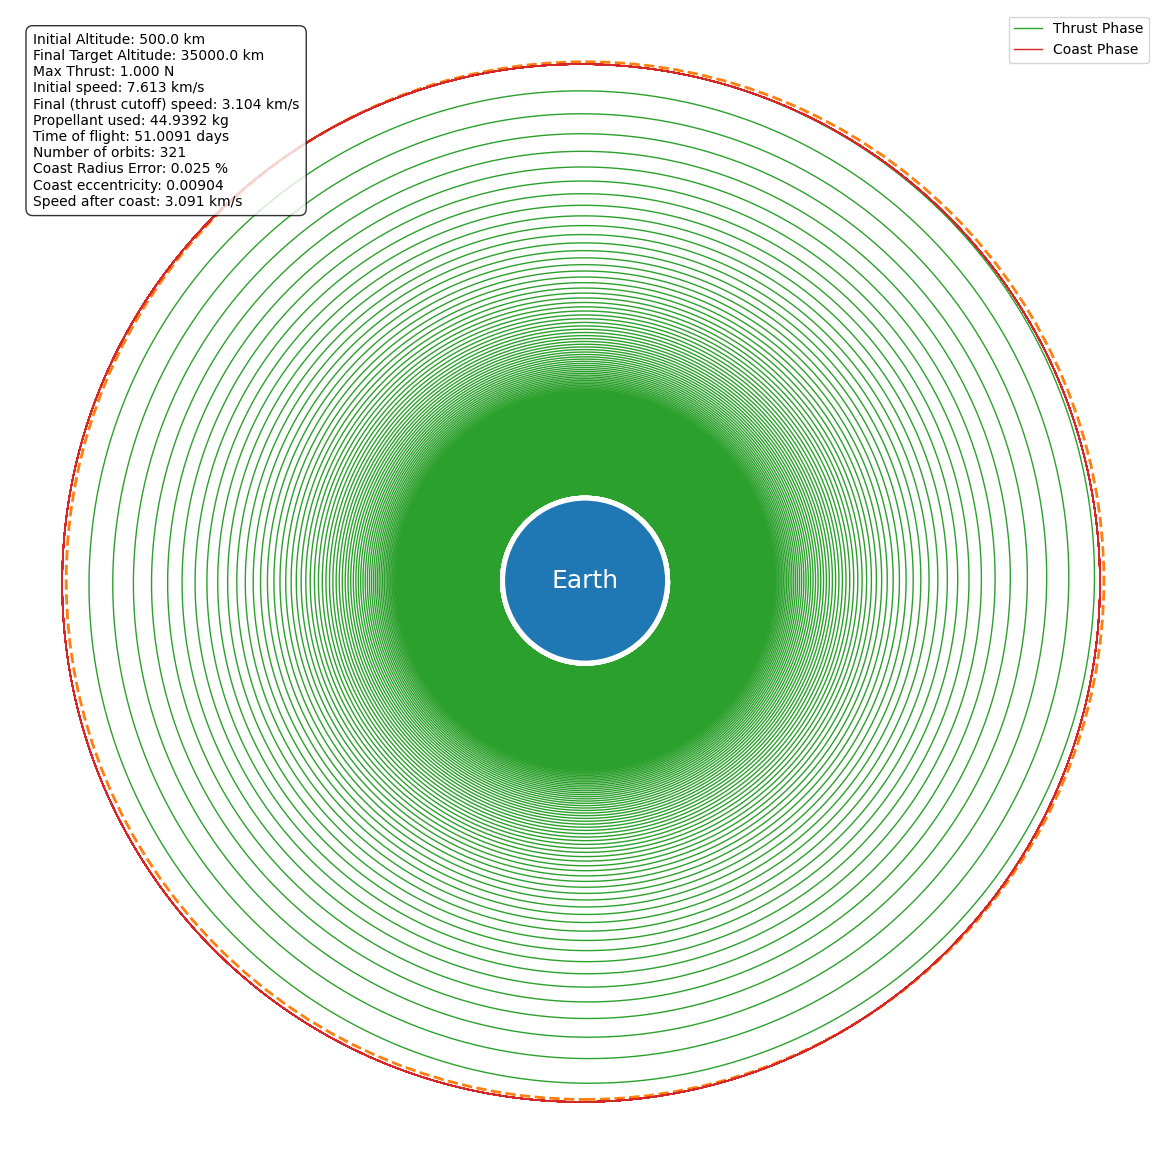

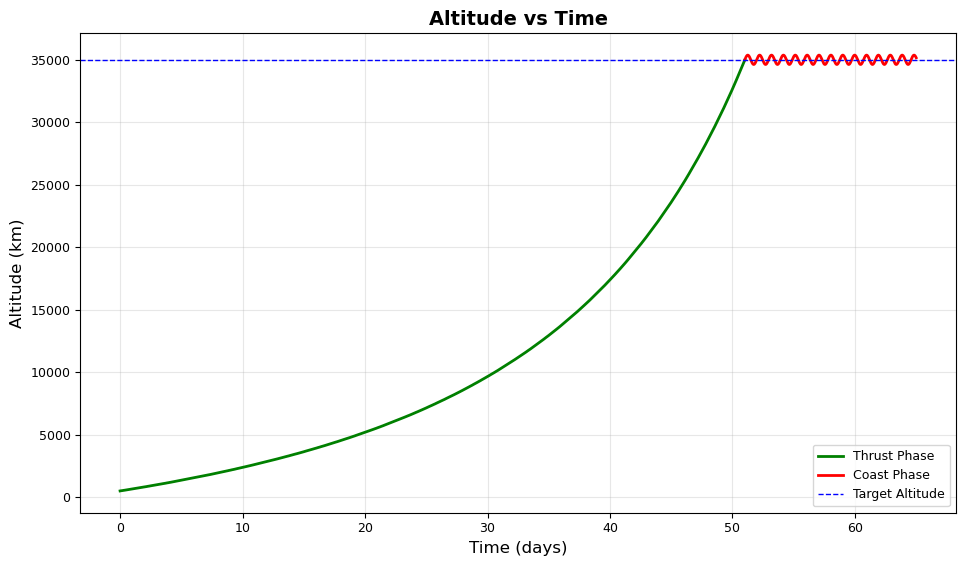

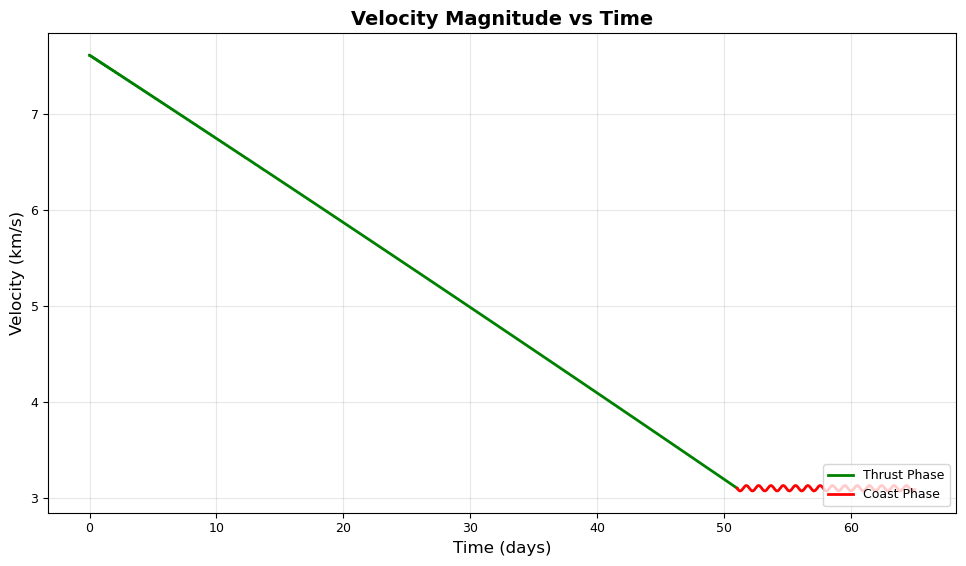

In [4]:
if __name__ == "__main__":
    run(show_plots=True)